<h1 align="center">Quantum Computing for Molecular Energy Calculations</h1>
<br>
<h3 align="center">Author: Arthur Murphy
<br>
  <i>Atomistic and Multiscale Computational Modeling in Physics, Chemistry, and Biochemistry
  <br>
  Faculty of Chemistry, University of Barcelona, Martí i Franquès, 1, 08028 Barcelona, Spain
  </i>
  <br><br>
  Advisors: Dr. David Muñoz Ramo, <i>Quantinuum</i>
  <br>
  Dr. Josep Maria Bofill Villà, <i>University of Barcelona</i>
</h3>


<h3 align="center">
 ABSTRACT
</h3>

Quantum Phase Estimation (QPE) is a foundational algorithm in quantum computing with transformative applications, particularly in the simulation of complex molecular systems. By directly measuring the eigenvalues of a unitary operator, QPE promises an exponential speedup over classical algorithms. In traditional computational chemistry, determining a molecule's ground state energy typically relies on the Full Configuration Interaction method, which exactly diagonalizes the time-independent Hamiltonian matrix. However, this approach scales exponentially and rapidly exhausts classical computational memory. Alternatively, QPE leverages the Time-Dependent Schrödinger Equation by applying powers of a time-evolution operator directly to a quantum state, allowing the system's exact physical rules to dictate its evolution. While QPE offers a definitive solution to the classical memory wall, executing its deep circuits for large systems on near-term quantum hardware is currently bottlenecked by physical decoherence and a lack of fault-tolerance. This study shows a comprehensive implementation of QPE simulated on classical hardware that calculates the ground state energy of a hydrogen molecule \($\text{H}_2$\) at equilibrium bond length within chemical accuracy. The simulation mirrors the exact sequence possible on quantum hardware to avoid explicit mathematical diagonalization: expressing the molecular Hamiltonian via second-quantization and converting it to physical qubit operators using the Jordan-Wigner mapping; constructing the unitary time-evolution operator via Trotterization; sequentially applying the unitary operator across the ancillary qubit register for phase kickback to encode the energy eigenvalues; and finally decoding the phases with the Inverse Quantum Fourier Transform, successfully extracting the system’s ground state energy directly from an initial Hartree-Fock state. This study is meant as an introduction to the framework that will allow future fault-tolerant quantum computers to escape classical memory limits when computing chemically significant eigenvalues, enabling a paradigm shift in computational chemistry and paving the way for advances in materials science and drug discovery.

### Packages Used

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector, Operator
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock
from qiskit.circuit.library import PauliEvolutionGate, UnitaryGate
from qiskit.synthesis import LieTrotter
import pyscf
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import display, Latex
from scipy.linalg import expm

### Experimental Setup

In [2]:
# Define our parameters
theta = -1.137306      # Known Full CI $E_GS$ of $H_2$ molecule
n_counting_qubits = 12 # Number of qubits performing estimation
                       # Determines precision as $1/2^N$ 
                       # IE: 12 qubits = 1/4096 = ~0.0009765
plt.rcParams.update({'font.size':14})

# Standard Aer simulator that mimics a perfect quantum computer
simulator = AerSimulator()
simulator.set_options(seed_simulator=42)

# Define H2 molecule at equilibrium bond length
driver = PySCFDriver(
    atom="H 0 0 0; H 0 0 0.735",
    basis="sto3g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM,
)
problem = driver.run()

# Instantiate the Jordan-Wigner Mapper
mapper = JordanWignerMapper()

# Map the Hamiltonian to a qubit operator
h2_op = mapper.map(problem.hamiltonian.second_q_op())

# For H2 in STO-3G, Jordan-Wigner will ALWAYS yield a 4-qubit operator
print(f"Number of qubits required: {h2_op.num_qubits}")

n_target_qubits = h2_op.num_qubits  # Number of qubits for the state |psi>
                                    # 4 for Jordan-Wigner mapping on $H_2$
target_qubits_list = list(range(n_counting_qubits,
                                n_counting_qubits + n_target_qubits))    



Number of qubits required: 4


### Quantum Circuit Buildout by Barrier
#### Build circuit, apply _H_ gates on ancilla, set target register to HF state

In [3]:
# Create a Quantum Circuit with 12 counting qubits + 4 target qubits 
qc = QuantumCircuit(n_counting_qubits + n_target_qubits, n_counting_qubits)

# Initialize the target qubits to the Hartree-Fock state
hf_state = HartreeFock(
    problem.num_spatial_orbitals,
    problem.num_particles,
    mapper,
)

# Append it to the target qubits
qc.compose(hf_state, qubits=target_qubits_list, inplace=True)

# Extract the Statevector directly from the current circuit
current_state = Statevector(qc)

print("Circuit initialized. The mathematical state of our qubits is:")
# Since Qiskit reads right-to-left (Target, Count2, Count1, Count0), 
# all counting qubits are `0` and the target is in the Hartree-Fock state
display(current_state.draw('latex'))


Circuit initialized. The mathematical state of our qubits is:


<IPython.core.display.Latex object>

In [4]:
# Apply Hadamard gates to all counting qubits (indices 0 through 11)
for qubit in range(n_counting_qubits):
    qc.h(qubit)
  
current_state = Statevector(qc)
print("Hadamard gates applied to counting qubits. State of the qubits is now:")
#display(current_state.draw('latex'))
display(Latex(current_state.draw('latex').data.replace('$$','$')))

# Barrier  
qc.barrier() 

Hadamard gates applied to counting qubits. State of the qubits is now:


<IPython.core.display.Latex object>

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=16, num_clbits=0, params=[]), qubits=(<Qubit register=(16, "q"), index=0>, <Qubit register=(16, "q"), index=1>, <Qubit register=(16, "q"), index=2>, <Qubit register=(16, "q"), index=3>, <Qubit register=(16, "q"), index=4>, <Qubit register=(16, "q"), index=5>, <Qubit register=(16, "q"), index=6>, <Qubit register=(16, "q"), index=7>, <Qubit register=(16, "q"), index=8>, <Qubit register=(16, "q"), index=9>, <Qubit register=(16, "q"), index=10>, <Qubit register=(16, "q"), index=11>, <Qubit register=(16, "q"), index=12>, <Qubit register=(16, "q"), index=13>, <Qubit register=(16, "q"), index=14>, <Qubit register=(16, "q"), index=15>), clbits=())

#### Trotterization

In [5]:
# CNOT Ladders with LieTrotter of single Trotter step synthesized into a matrix that's exponentially applied
# (Classical implementation that abstracts the exponential gate explosion to ~7M gates)
tau = 1.0 
dt_target = 0.1  # Target Trotter time-step size to keep errors low

# Synthesize exactly ONE single base step; 
# evolves for exactly 'dt_target' time with 1 repetition
base_evo_gate = PauliEvolutionGate(h2_op, time=dt_target)
base_step_circuit = LieTrotter(reps=1).synthesize(base_evo_gate)

# Convert the single step into a matrix instead of a gate
base_step_matrix = Operator(base_step_circuit).data

# Evolve through exponentiating that matrix 2**j
for j in range(n_counting_qubits):
    evo_time = tau * (2 ** j)
    
    # Calculate how many total base slices this counting qubit needs
    reps = max(1, int(np.ceil(evo_time / dt_target)))
    
    # 2. Classically raise the physical circuit's matrix to the power of reps
    trotter_matrix = np.linalg.matrix_power(base_step_matrix, reps)
    
    # 3. Create a gate and append it
    evo_gate = UnitaryGate(trotter_matrix, label="$U^{"+str(j)+"}_T$")
    qc.append(evo_gate.control(1), [j] + target_qubits_list)

qc.barrier()

# 1. See total counts of high-level gates (e.g., 'StepOperator', 'mcx', 'controlled_U')
print("High-level operations:", qc.count_ops())

# 2. Decompose the circuit down to see the underlying basic gates
decomposed_circuit = qc.decompose()
print("Decomposed gate counts:", decomposed_circuit.count_ops())
print("Decomposed circuit depth:", decomposed_circuit.depth())



High-level operations: OrderedDict({'h': 12, 'c-unitary': 12, 'x': 2, 'barrier': 2})
Decomposed gate counts: OrderedDict({'u': 3086, 'cx': 2832, 'rz': 1920, 'h': 240, 'barrier': 2})
Decomposed circuit depth: 5605


#### IQFT

In [6]:
# Step 4: Apply the Inverse QFT
# Provided by Qiskit, just set inverse=True
# Only applied to counting qubits, not the target qubits
iqft = QFT(num_qubits=n_counting_qubits, inverse=True, name='IQFT')

# Append the IQFT instruction block to our circuit
qc.append(iqft, range(n_counting_qubits))

qc.barrier()

/tmp/ipykernel_11110/3330784533.py:4: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(num_qubits=n_counting_qubits, inverse=True, name='IQFT')


CircuitInstruction(operation=Instruction(name='barrier', num_qubits=16, num_clbits=0, params=[]), qubits=(<Qubit register=(16, "q"), index=0>, <Qubit register=(16, "q"), index=1>, <Qubit register=(16, "q"), index=2>, <Qubit register=(16, "q"), index=3>, <Qubit register=(16, "q"), index=4>, <Qubit register=(16, "q"), index=5>, <Qubit register=(16, "q"), index=6>, <Qubit register=(16, "q"), index=7>, <Qubit register=(16, "q"), index=8>, <Qubit register=(16, "q"), index=9>, <Qubit register=(16, "q"), index=10>, <Qubit register=(16, "q"), index=11>, <Qubit register=(16, "q"), index=12>, <Qubit register=(16, "q"), index=13>, <Qubit register=(16, "q"), index=14>, <Qubit register=(16, "q"), index=15>), clbits=())

#### Measure the Results

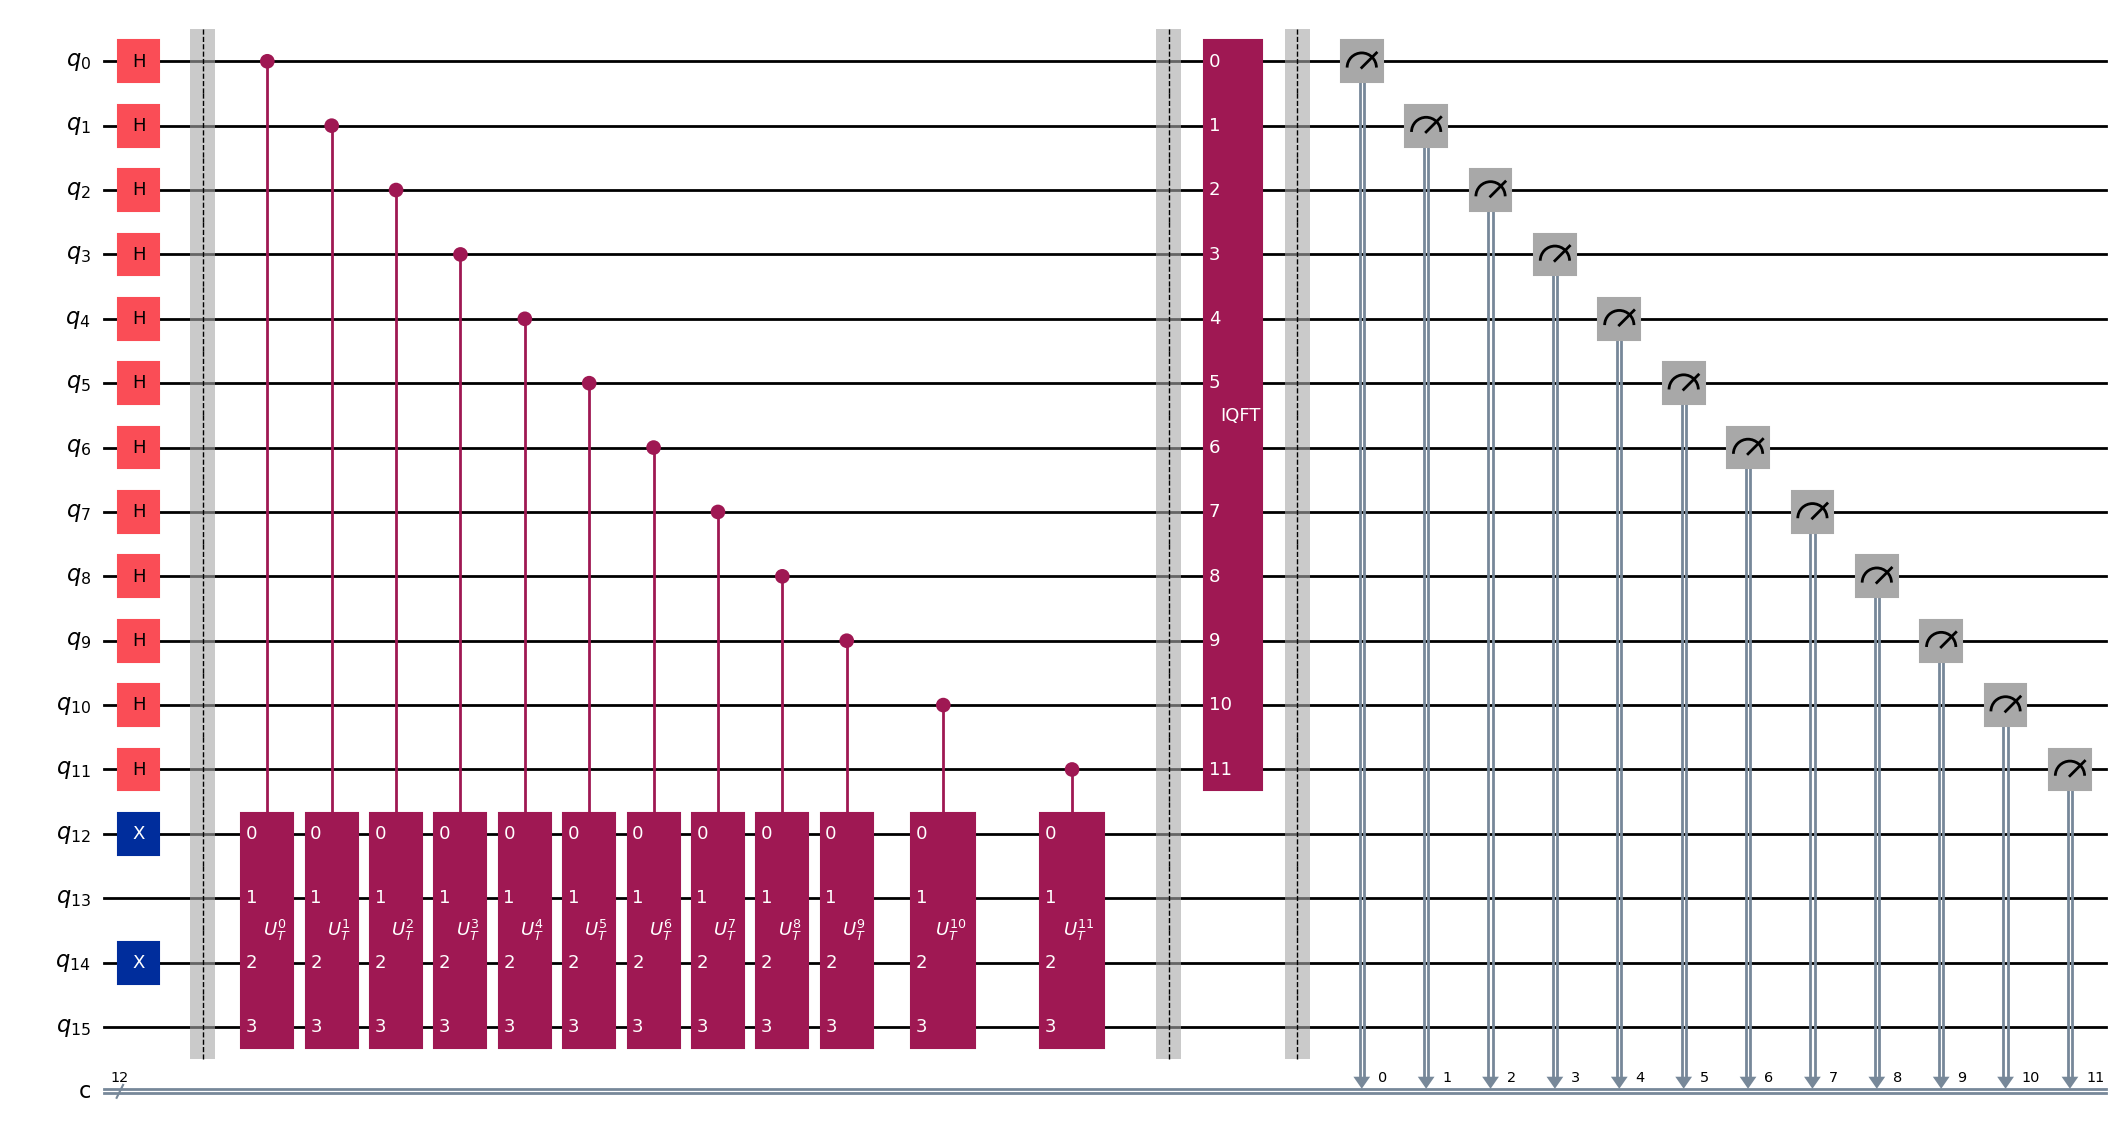

In [7]:
# Measure the counting qubits and store the output in the classical bits
for j in range(n_counting_qubits):
    qc.measure(j, j)
    
# Draw out the circuit diagram, step-by-step
# (requires maplotlib and pdflatex or pillow depending on environment backend)
qc.draw('mpl', fold=-1)

### Transpile & Run Simulation

Transpilation took: 0.1450023651123047 seconds

--- Simulation using 5 shots ---
Raw Simulation took : 0.5422036647796631 seconds
Measurement Counts  : {'010010111010': 1, '010010111011': 4}
Average Phase       : 0.295605 ± 0.000098
Average Energy      : -1.137375 ± 0.000614 Hartree
Peak String         : 010010111011
Peak Occurrence     : 4 times (80.0%)
Peak Phase          : 0.295654
Peak Energy         : -1.137682 Hartree



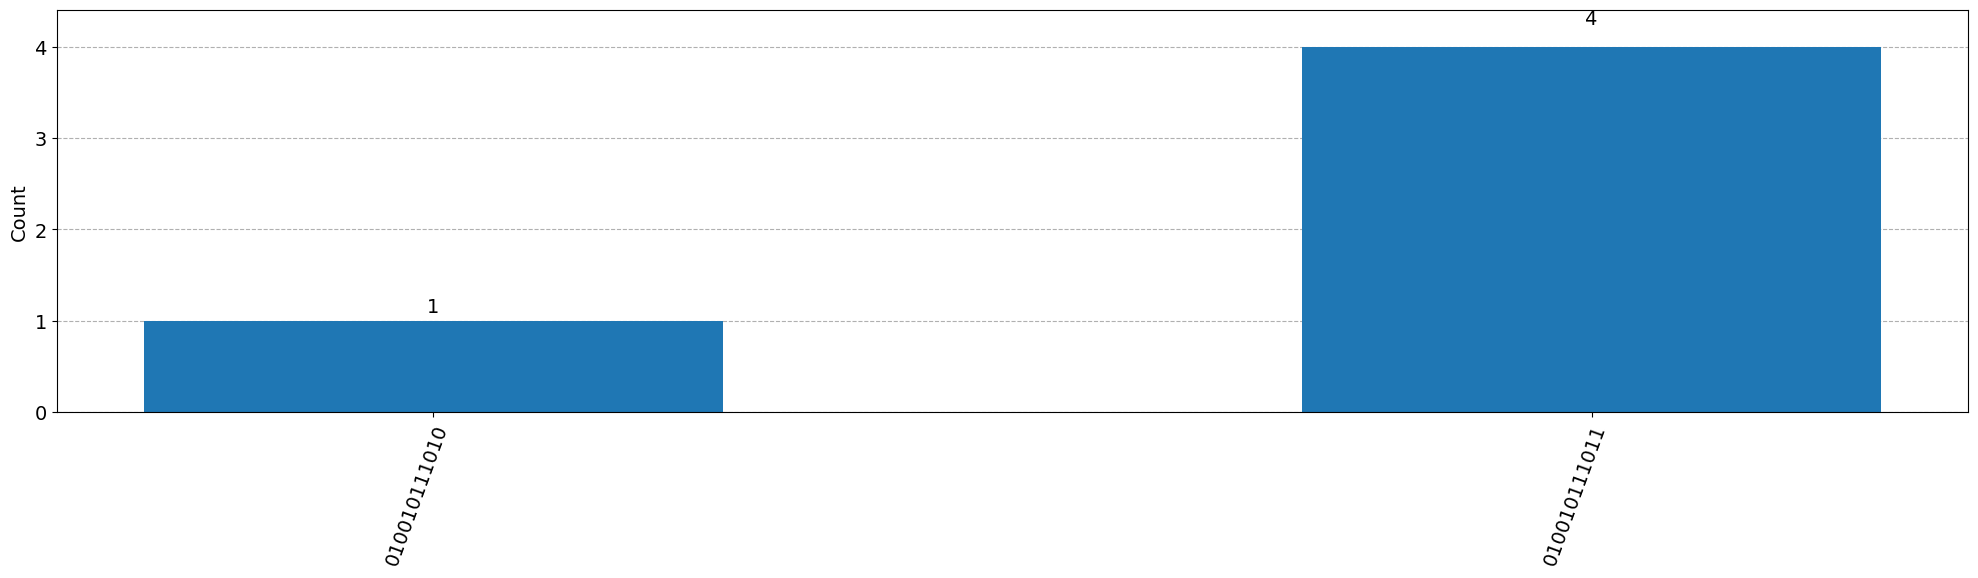




--- Simulation using 10 shots ---
Raw Simulation took : 0.5428714752197266 seconds
Measurement Counts  : {'010010111010': 2, '010010111011': 8}
Average Phase       : 0.295605 ± 0.000098
Average Energy      : -1.137375 ± 0.000614 Hartree
Peak String         : 010010111011
Peak Occurrence     : 8 times (80.0%)
Peak Phase          : 0.295654
Peak Energy         : -1.137682 Hartree



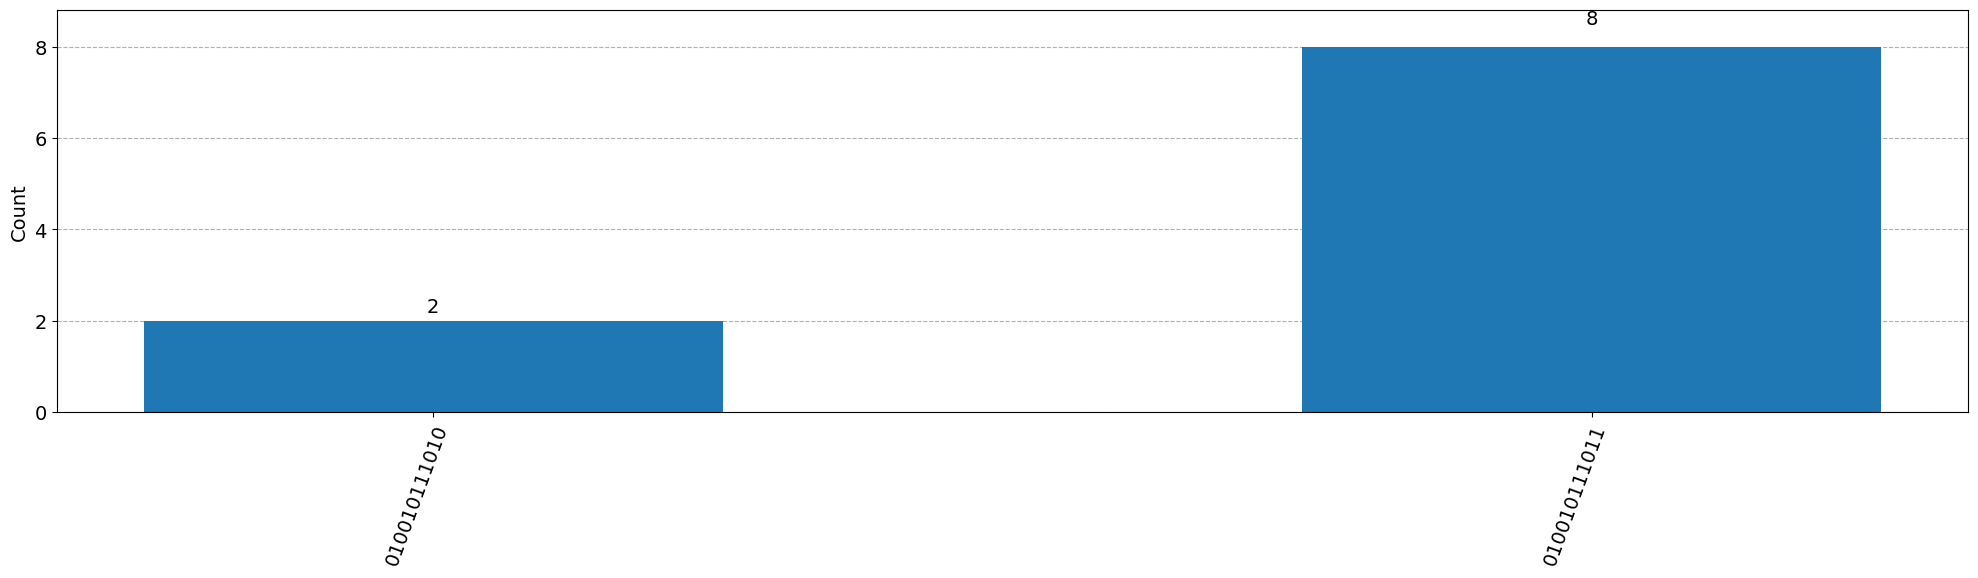




--- Simulation using 100 shots ---
Raw Simulation took : 0.5539448261260986 seconds
Measurement Counts  : {'010011010100': 1, '010010111100': 3, '000010010011': 1, '010010111011': 82, '010010111010': 13}
Average Phase       : 0.293093 ± 0.025857
Average Energy      : -1.121590 ± 0.162467 Hartree
Peak String         : 010010111011
Peak Occurrence     : 82 times (82.0%)
Peak Phase          : 0.295654
Peak Energy         : -1.137682 Hartree



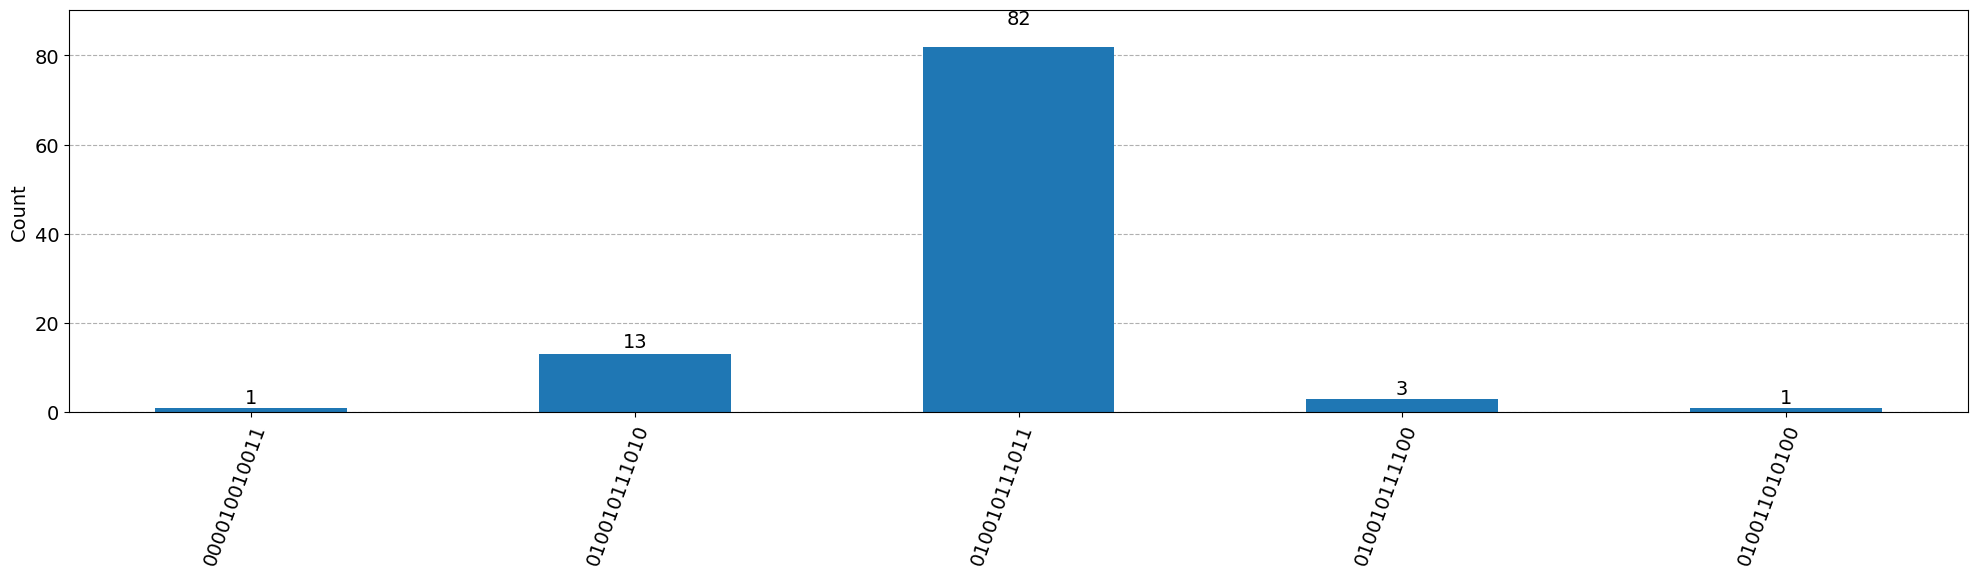




--- Simulation using 1000 shots ---
Raw Simulation took : 0.5727174282073975 seconds
Measurement Counts  : {'010011010100': 1, '010011011010': 1, '010010111110': 2, '010011011011': 1, '010011000101': 1, '000010010011': 8, '010010110111': 5, '010010111111': 2, '010010011100': 1, '010010110101': 4, '010010011011': 1, '010011000000': 2, '010011000010': 1, '010010111101': 12, '010010111100': 25, '010011001001': 1, '010010111001': 22, '010010111011': 766, '010010111010': 117, '010011010101': 1, '010011000011': 3, '010011001110': 2, '010011011101': 1, '010011000100': 1, '010010110001': 2, '010011101001': 1, '010010001101': 1, '000010010010': 3, '010001110010': 1, '010010110010': 1, '010011000001': 1, '010010111000': 2, '010010110110': 6, '010010110011': 1}
Average Phase       : 0.292775 ± 0.027119
Average Energy      : -1.119593 ± 0.170395 Hartree
Peak String         : 010010111011
Peak Occurrence     : 766 times (76.6%)
Peak Phase          : 0.295654
Peak Energy         : -1.137682 Hartr

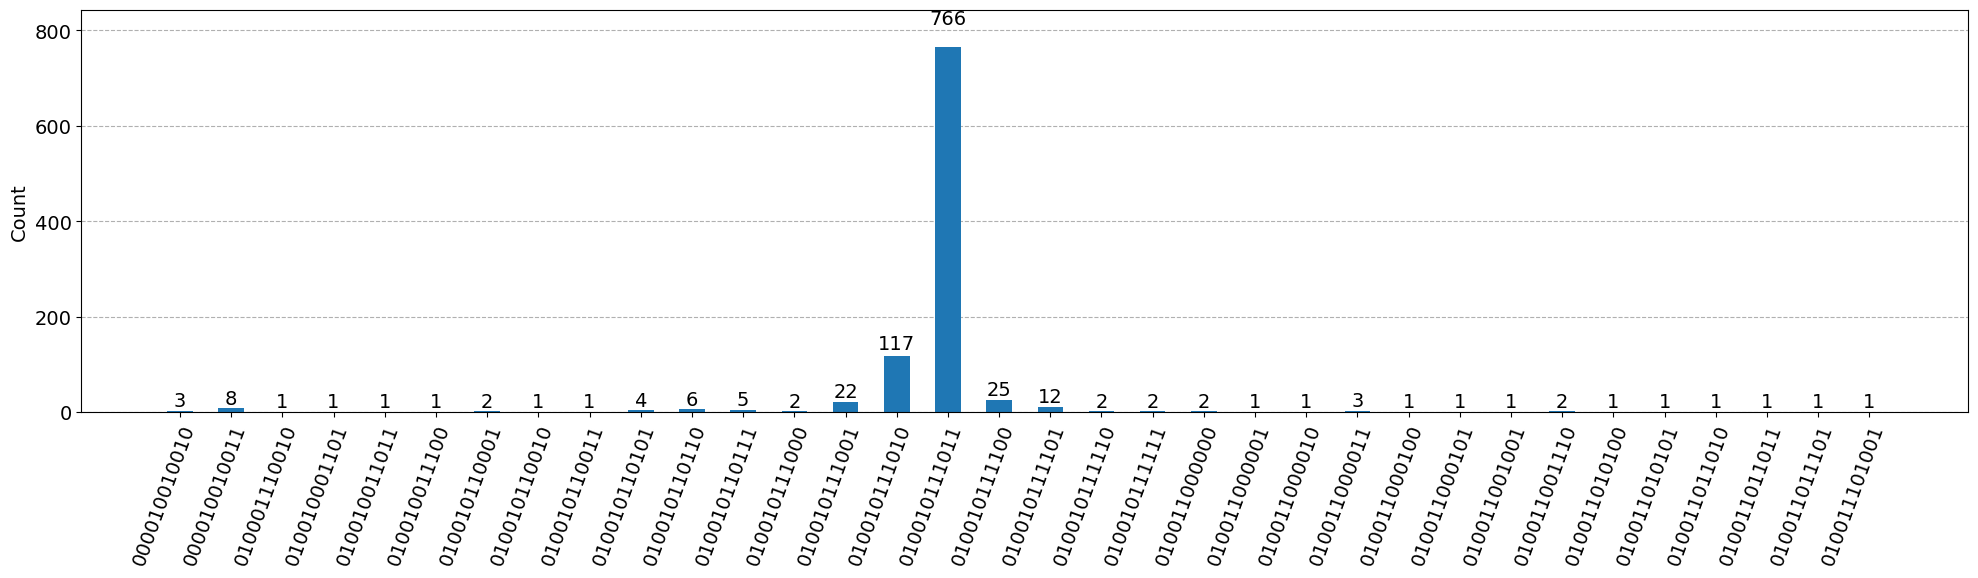




--- Simulation using 10000 shots ---
Raw Simulation took : 0.5180346965789795 seconds
Measurement Counts  : {'010011010101': 1, '010011010100': 1, '010011101001': 1, '010011001110': 2, '010001110010': 1, '010011010110': 1, '010010011011': 1, '010001101000': 1, '010000111011': 1, '010001100001': 1, '010011001011': 2, '010100000000': 1, '010011011010': 1, '010011011011': 2, '010010100101': 2, '010011010011': 1, '010001000001': 1, '010011111010': 1, '010101001111': 1, '010010001111': 1, '010010101011': 2, '010011010000': 5, '010010011000': 1, '000001111110': 1, '010011000000': 16, '010100101101': 1, '010001011110': 1, '010010110010': 8, '000010100000': 1, '010011001100': 2, '010010110000': 6, '010010100100': 2, '010010110011': 12, '010011000001': 13, '010010110110': 33, '010000101011': 1, '010011101110': 1, '010110101110': 1, '010010001101': 3, '010010101110': 2, '010010111010': 1090, '010001111001': 1, '010001111101': 1, '010011000111': 6, '010011001000': 2, '010011101000': 1, '000010

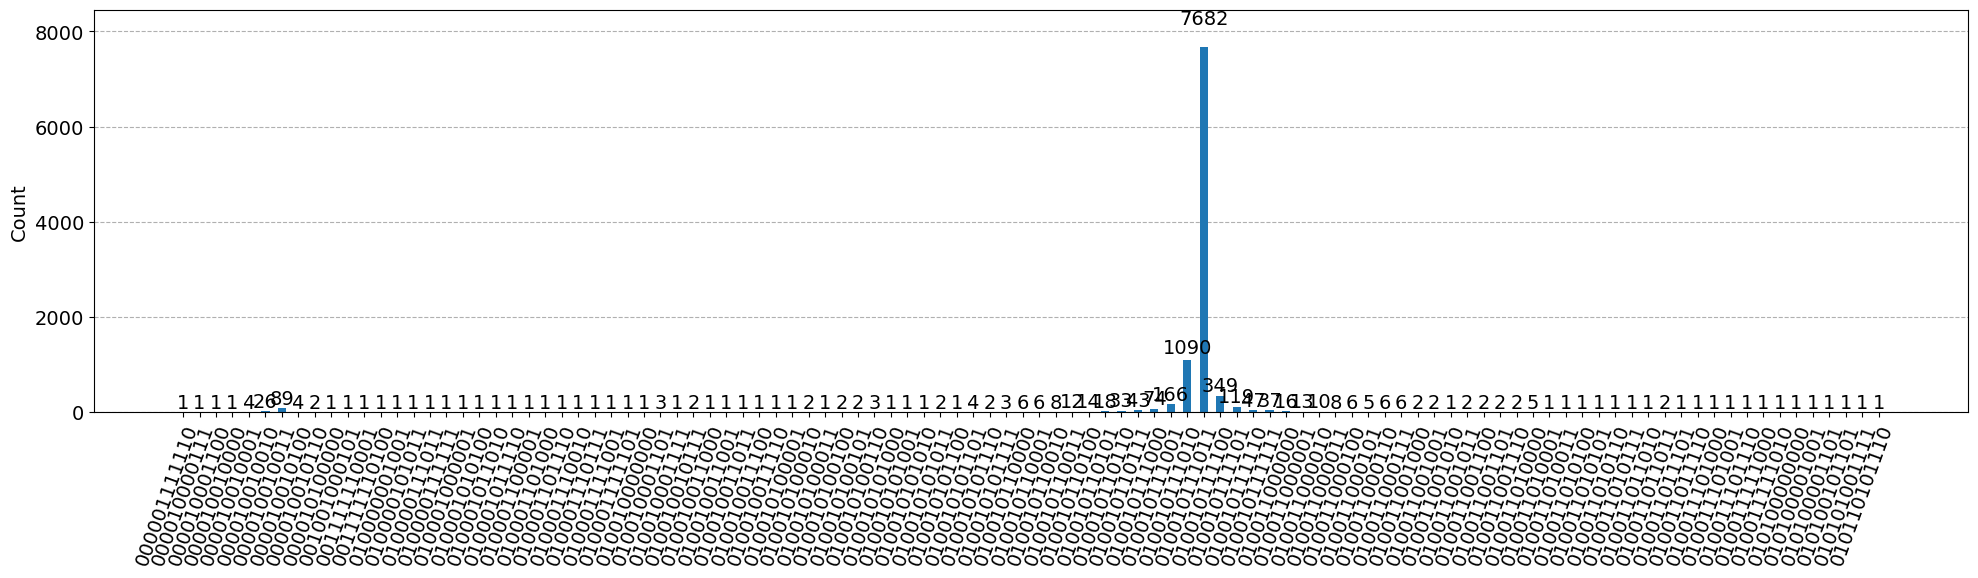

In [8]:
# Transpile the circuit (optimizes the gates for the specific backend)
start_transpile = time.time()
compiled_circuit = transpile(qc, simulator, optimization_level=2, seed_transpiler=42)
end_transpile = time.time()
print(f"Transpilation took: {end_transpile - start_transpile} seconds\n")

for shot_num in [5, 10, 100, 1000, 10000]:
    # Run the simulation
    job = simulator.run(compiled_circuit, shots=shot_num)
    result = job.result()
    print(f"--- Simulation using {shot_num} shots ---")
    print(f"Raw Simulation took : {result.time_taken} seconds")

    counts = result.get_counts()
    print("Measurement Counts  :", counts)

    # Lists to store values for statistical analysis
    phases = []
    energies = []
    weights = []

    nuclear_repulsion_energy = problem.nuclear_repulsion_energy

    for binary_string, count in counts.items():
        # Decode binary string to phase fraction (theta)
        measured_integer = int(binary_string, 2)
        estimated_theta = measured_integer / (2 ** n_counting_qubits)
        
        # Adjust for negative phase wrapping
        if estimated_theta > 0.5:
            estimated_theta -= 1.0
            
        # Convert phase to total energy (electronic + nuclear repulsion)
        estimated_energy = -(2 * np.pi * estimated_theta) / tau
        total_energy = estimated_energy + nuclear_repulsion_energy

        phases.append(estimated_theta)
        energies.append(total_energy)
        weights.append(count)

    # Convert to numpy arrays for calculation
    phases = np.array(phases)
    energies = np.array(energies)
    weights = np.array(weights)

    # Compute weighted average and standard deviation
    avg_phase = np.average(phases, weights=weights)
    std_phase = np.sqrt(np.average((phases - avg_phase)**2, weights=weights))

    avg_energy = np.average(energies, weights=weights)
    std_energy = np.sqrt(np.average((energies - avg_energy)**2, weights=weights))

    print(f"Average Phase       : {avg_phase:.6f} ± {std_phase:.6f}")
    print(f"Average Energy      : {avg_energy:.6f} ± {std_energy:.6f} Hartree")

    # 1. Find the peak measurement string (mode) and its count
    peak_string = max(counts, key=counts.get)
    peak_count = counts[peak_string]
    # 2. Decode the peak measurement
    peak_integer = int(peak_string, 2)
    peak_theta = peak_integer / (2 ** n_counting_qubits)
    if peak_theta > 0.5:
        peak_theta -= 1.0
    peak_energy = (-(2 * np.pi * peak_theta) / tau) + nuclear_repulsion_energy
    # 3. Print the results (updated print section)
    print(f"Peak String         : {peak_string}")
    print(f"Peak Occurrence     : {peak_count} times ({(peak_count/shot_num)*100:1}%)")
    print(f"Peak Phase          : {peak_theta:.6f}")
    print(f"Peak Energy         : {peak_energy:.6f} Hartree\n")

    # Plot the results in a bar histogram
    fig = plot_histogram(counts, figsize=(20,6))
    display(fig)
    print("\n\n")


#### Pull out results for 10k shot run with at least 1% probability amplitude

In [9]:
# Create a summary of all measurements found
print(f"--- Analysis Results ({job.result().results[0].shots} total shots) ---")
for binary_string, count in counts.items():
    # Convert binary to decimal integer
    measured_integer = int(binary_string, 2)
    
    # Calculate estimated phase theta
    estimated_theta = measured_integer / (2 ** n_counting_qubits)
    
    # If theta is > 0.5, it likely represents a negative energy phase wrap
    if estimated_theta > 0.5:
        estimated_theta -= 1.0

    # Convert phase back to Energy
    estimated_energy = -(2 * np.pi * estimated_theta) / tau
    nuclear_repulsion_energy = problem.nuclear_repulsion_energy
    total_energy = estimated_energy + nuclear_repulsion_energy

    # Calculate percentage
    percentage = (count / job.result().results[0].shots) * 100
    
    if percentage >= 1.0:
        print(f"\nMeasured String : {binary_string} (occurred {count} times | {percentage:.1f}%)")
        print(f"Estimated Phase : {estimated_theta}")
        print(f"Estimated H2 Nuclear Repulsion Energy: {nuclear_repulsion_energy} Hartree")
        print(f"Estimated H2 Electronic Energy: {estimated_energy} Hartree")
        print(f"Total H2 Ground State Energy: {total_energy} Hartree")
    
print(f"\n------------------------")


--- Analysis Results (10000 total shots) ---

Measured String : 010010111010 (occurred 1090 times | 10.9%)
Estimated Phase : 0.29541015625
Estimated H2 Nuclear Repulsion Energy: 0.7199689944489797 Hartree
Estimated H2 Electronic Energy: -1.8561167533416258 Hartree
Total H2 Ground State Energy: -1.1361477588926463 Hartree

Measured String : 010010111011 (occurred 7682 times | 76.8%)
Estimated Phase : 0.295654296875
Estimated H2 Nuclear Repulsion Energy: 0.7199689944489797 Hartree
Estimated H2 Electronic Energy: -1.8576507341295114 Hartree
Total H2 Ground State Energy: -1.1376817396805317 Hartree

Measured String : 010010111100 (occurred 349 times | 3.5%)
Estimated Phase : 0.2958984375
Estimated H2 Nuclear Repulsion Energy: 0.7199689944489797 Hartree
Estimated H2 Electronic Energy: -1.859184714917397 Hartree
Total H2 Ground State Energy: -1.1392157204684175 Hartree

Measured String : 010010111101 (occurred 119 times | 1.2%)
Estimated Phase : 0.296142578125
Estimated H2 Nuclear Repulsion 